In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
from sklearn.preprocessing import MinMaxScaler,StandardScaler,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import train_test_split,GridSearchCV
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('E:/makbig/Data Science with AI-ML/.venv/practical/ml_practice/Classification/Non_linear_classification/Random_forest/CollegePlacement.csv')
df

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No
...,...,...,...,...,...,...,...,...,...,...
9995,CLG0021,119,8.41,8.29,4,No,1,8,0,Yes
9996,CLG0098,70,9.25,9.34,7,No,0,7,2,No
9997,CLG0066,89,6.08,6.25,3,Yes,3,9,5,No
9998,CLG0045,107,8.77,8.92,3,No,7,5,1,No


In [3]:
df.drop('College_ID',axis=1,inplace=True)

In [4]:
x=df.drop('Placement',axis=1)
y=df[['Placement']]
x.head()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed
0,107,6.61,6.28,8,No,8,8,4
1,97,5.52,5.37,8,No,7,8,0
2,109,5.36,5.83,9,No,3,1,1
3,122,5.47,5.75,6,Yes,1,6,1
4,96,7.91,7.69,7,No,8,10,2


In [5]:
y.head()

,Placement
0,No
1,No
2,No
3,No
4,No


In [6]:
x.drop('Prev_Sem_Result',axis=1,inplace=True)
x.columns

Index(['IQ', 'CGPA', 'Academic_Performance', 'Internship_Experience',
       'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed'],
      dtype='object')

In [7]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
x_train.head()

,IQ,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed
9069,110,8.25,3,No,2,2,4
2603,82,7.98,1,No,1,3,5
7738,103,9.30,2,Yes,5,6,3
1579,87,9.03,1,Yes,2,4,4
5058,97,5.61,8,Yes,5,6,3


In [8]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

x_train["Internship_Experience"] = le.fit_transform(x_train["Internship_Experience"])
x_test["Internship_Experience"] = le.transform(x_test["Internship_Experience"])


In [9]:
num_cols_minmax = ["IQ", "CGPA"]
num_cols_std = [
    "Academic_Performance",
    "Internship_Experience",
    "Extra_Curricular_Score",
    "Communication_Skills",
    "Projects_Completed",
]


In [10]:
preprocessor=ColumnTransformer(
    transformers=[
        ('minmax',MinMaxScaler(feature_range=(0,1)),num_cols_minmax),
        ('standard',StandardScaler(),num_cols_std)
    ],
    remainder='passthrough'
)

In [11]:
pipeline=ImbPipeline(
    steps=[
        ('preprocess',preprocessor),
        ('smote',SMOTE(random_state=42)),
        ('model',XGBClassifier())
    ]
)

In [12]:
param_grid = {
    'model__n_estimators': [50, 100, 200, 300, 500]
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [13]:
grid.fit(x_train,y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('minmax', ...), ('standard', ...)]"


In [14]:
ypred=grid.predict(x_test)
ypred

array([0, 0, 0, ..., 1, 0, 1], shape=(3000,))

In [15]:
res=pd.DataFrame(columns=['actual','predicted'])
res['actual']=y_test
res['predicted']=ypred
res.reset_index()
res.head()

,actual,predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,1,1


Accuracy: 0.997
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2511
           1       0.98      1.00      0.99       489

    accuracy                           1.00      3000
   macro avg       0.99      1.00      0.99      3000
weighted avg       1.00      1.00      1.00      3000



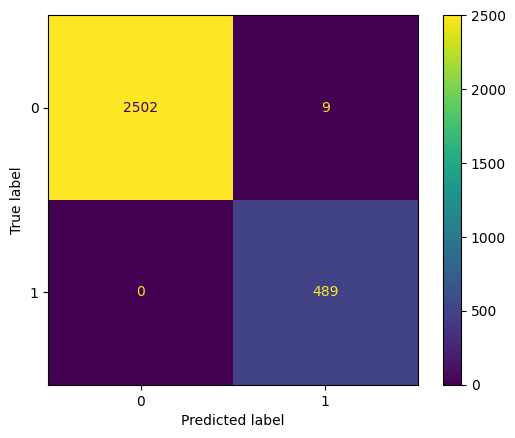

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, ypred))
print(classification_report(y_test, ypred))
ConfusionMatrixDisplay.from_estimator(grid, x_test, y_test)
plt.show()